# Analyse exploratoire des ventes (Boulangerie française)

Ce notebook a pour objectif d'explorer les données de ventes journalières afin de :
- Comprendre la dynamique des ventes
- Identifier les tendances et saisonnalités
- Préparer les données pour la modélisation prédictive

## 1. Import des librairies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 2. Chargement et inspection des données

Nous chargeons le dataset contenant les ventes journalières par produit.

In [17]:
df = pd.read_csv("../data/raw/daily_sales_french_bakery.csv")
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 57046 entries, 0 to 57045
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unique_id   57046 non-null  str    
 1   ds          57046 non-null  str    
 2   y           57046 non-null  float64
 3   unit_price  57046 non-null  float64
dtypes: float64(2), str(2)
memory usage: 1.7 MB


,y,unit_price
count,57046.000000,57046.000000
mean,9.792814,3.631011
std,32.327068,3.909706
min,0.000000,0.000000
25%,0.000000,1.400000
50%,0.900000,2.000000
75%,8.000000,4.500000
max,919.100000,60.000000


## 3. Préparation de la variable temporelle

La colonne 'ds' est convertie en format datetime afin de créer une série temporelle exploitable.

In [18]:
df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values("ds")
df = df.set_index("ds")

## 4. Agrégation des ventes journalières

Les données étant multi-produits, nous agrégeons les ventes pour obtenir une série globale journalière.

In [19]:
daily_sales = df.groupby(df.index)["y"].sum().asfreq("D")

## 5. Analyse visuelle des ventes

Nous observons l’évolution des ventes totales dans le temps.

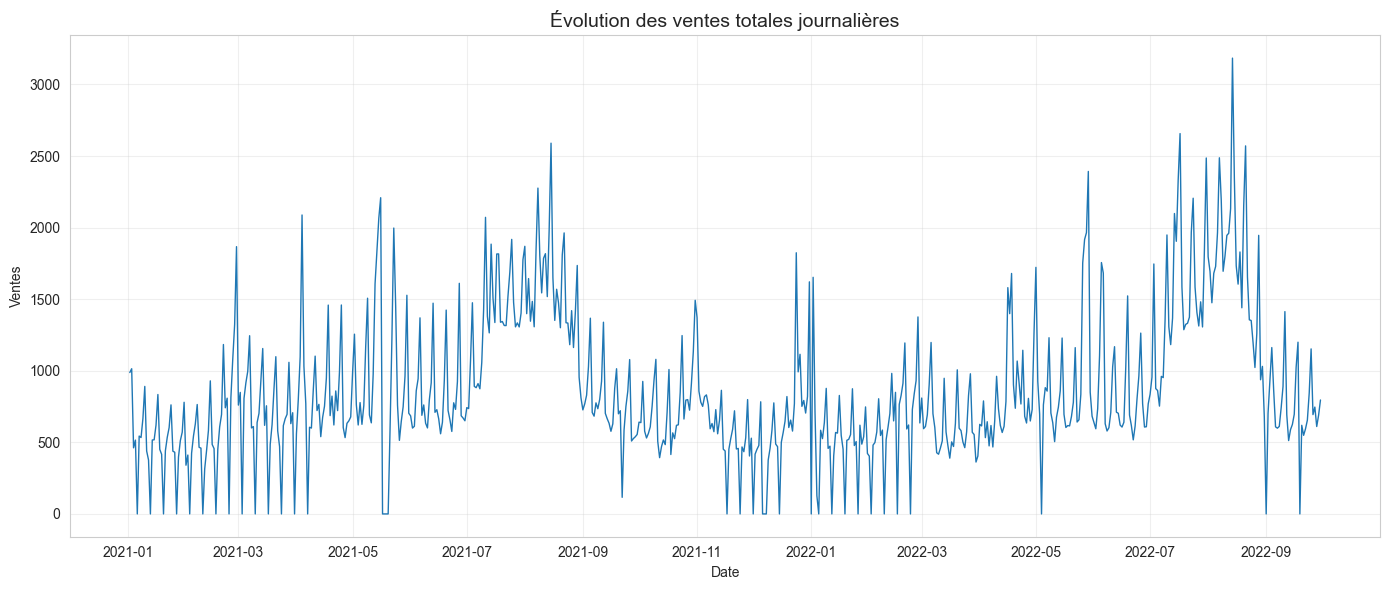

In [11]:
plt.figure(figsize=(14,6))
plt.plot(daily_sales, linewidth=1)
plt.title("Évolution des ventes totales journalières", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Ventes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Analyse de la tendance à l’aide d’une moyenne mobile

La moyenne mobile sur 30 jours permet d’identifier la tendance générale en réduisant le bruit journalier.

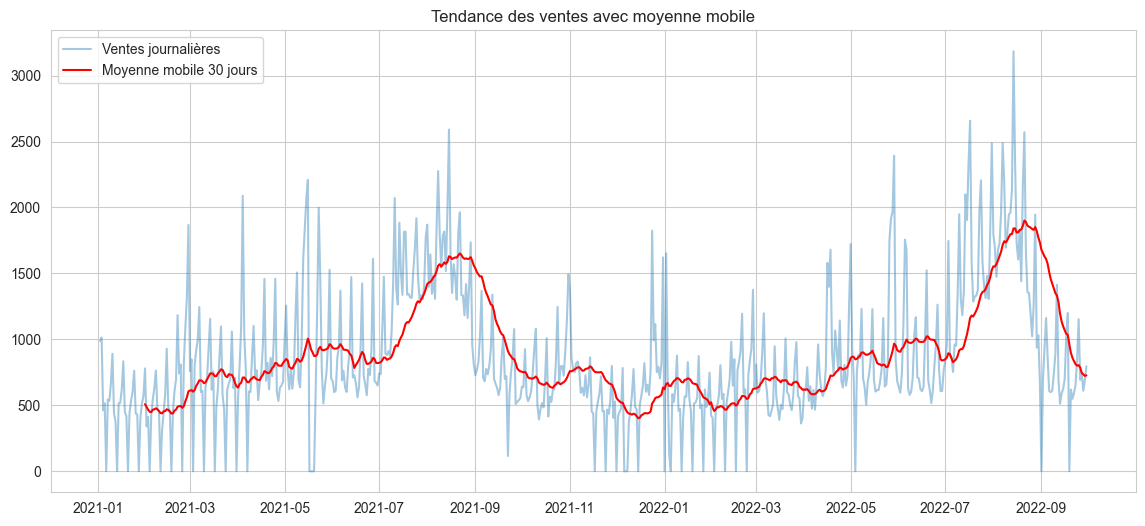

In [16]:
rolling_30 = daily_sales.rolling(30).mean()

plt.figure(figsize=(14,6))
plt.plot(daily_sales, alpha=0.4, label="Ventes journalières")
plt.plot(rolling_30, color="red", label="Moyenne mobile 30 jours")
plt.legend()
plt.title("Tendance des ventes avec moyenne mobile")
plt.show()